# Credit Default Risk Analysis
### Vitto DS Intern Assessment — Confidential

**Dataset:** UCI Credit Card Default · 30,000 clients · Taiwan, Apr–Sep 2005


## 00 · Setup & Data Profiling

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline
import xgboost as xgb

# ── Global constants ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.20
N_FOLDS      = 5

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
print("✅ Environment ready.")

✅ Environment ready.


In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv("UCI_Credit_Card.csv")

print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes.to_string()}")
print(f"\nNull counts:\n{df.isnull().sum().to_string()}")

vc = df["default.payment.next.month"].value_counts()
print(f"\nClass balance:\n{vc.to_string()}")
print(f"\nDefault rate: {vc[1] / len(df) * 100:.2f}%")

Shape: (30000, 25)

Column dtypes:
ID                              int64
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month      int64

Null counts:
I

## 01 · Exploratory Data Analysis

### Distributions of LIMIT_BAL, AGE, and PAY_0

> **Anomalies to note:**
> - `LIMIT_BAL` is strongly right-skewed — a small number of clients hold very high credit limits.
> - `PAY_0` contains values **-2** (no consumption) and **-1** (paid duly) alongside positive delay codes.
>   These are documented ambiguities in the dataset (see §02 for handling).


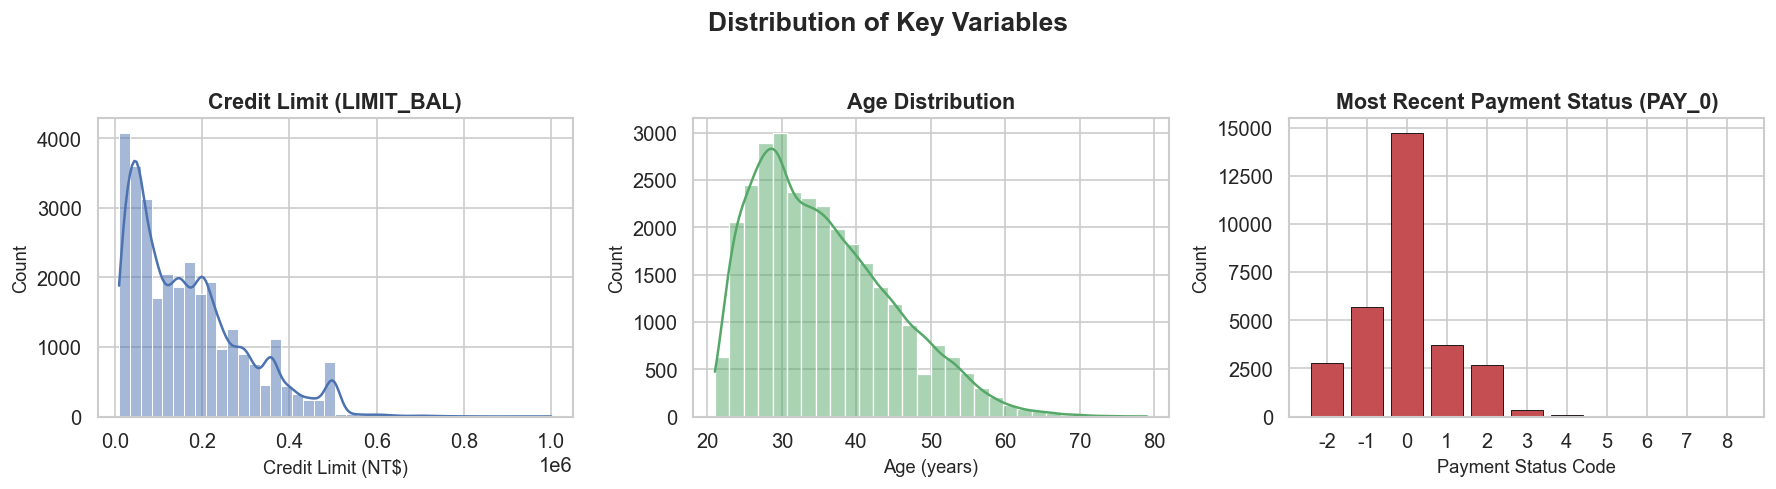

In [3]:
# ── Plot 1: Distributions ─────────────────────────────────────────────────────
TARGET = "default.payment.next.month"

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Distribution of Key Variables", fontweight="bold", y=1.02)

sns.histplot(df["LIMIT_BAL"], bins=40, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Credit Limit (LIMIT_BAL)")
axes[0].set_xlabel("Credit Limit (NT$)")
axes[0].set_ylabel("Count")

sns.histplot(df["AGE"], bins=30, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Age Distribution")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("Count")

pay0_vc = df["PAY_0"].value_counts().sort_index()
axes[2].bar(pay0_vc.index.astype(str), pay0_vc.values, color="#C44E52", edgecolor="black", lw=0.5)
axes[2].set_title("Most Recent Payment Status (PAY_0)")
axes[2].set_xlabel("Payment Status Code")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig("plot_01_distributions.png", bbox_inches="tight")
plt.show()

### Default Rates by Demographic Segment

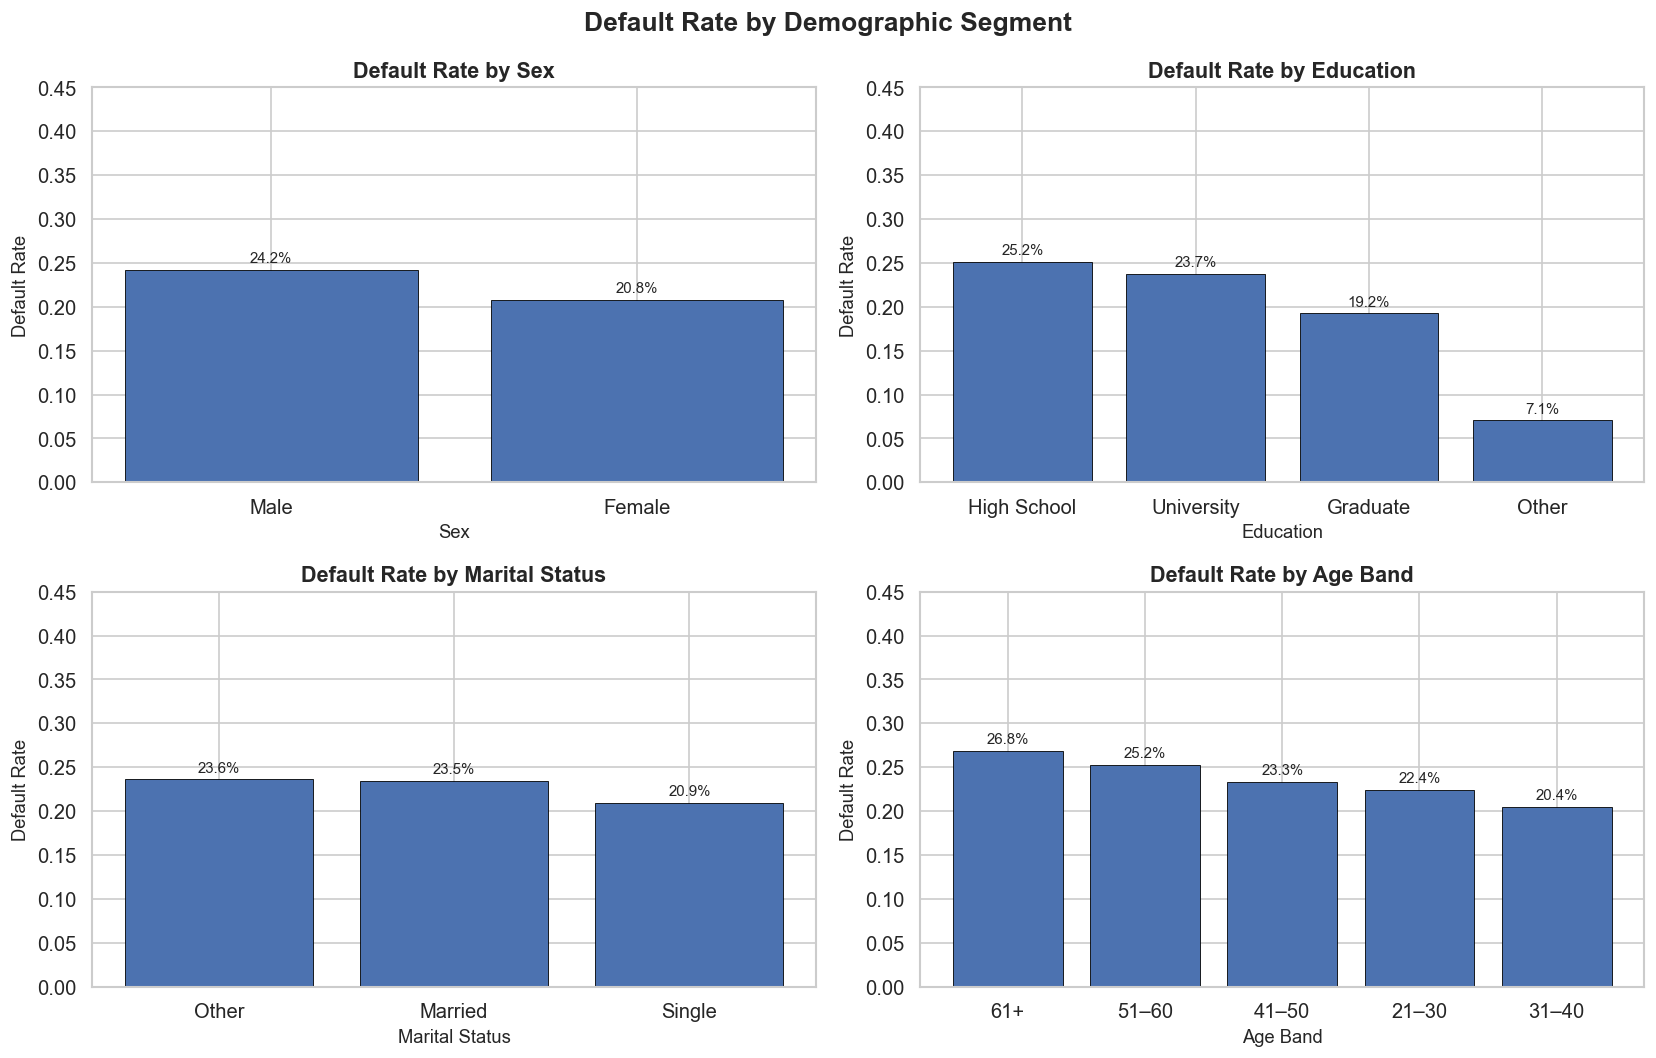

In [4]:
# ── Plot 2: Default rates by demographics ─────────────────────────────────────
edu_map = {1: "Graduate", 2: "University", 3: "High School", 4: "Other", 5: "Other", 6: "Other", 0: "Other"}
sex_map = {1: "Male", 2: "Female"}
mar_map = {0: "Other", 1: "Married", 2: "Single", 3: "Other"}

df["AGE_BAND"]  = pd.cut(df["AGE"], bins=[20,30,40,50,60,80], labels=["21–30","31–40","41–50","51–60","61+"])
df["EDU_LABEL"] = df["EDUCATION"].map(edu_map)
df["SEX_LABEL"] = df["SEX"].map(sex_map)
df["MAR_LABEL"] = df["MARRIAGE"].map(mar_map)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Default Rate by Demographic Segment", fontweight="bold")

for ax, col, title in zip(
    axes.flat,
    ["SEX_LABEL", "EDU_LABEL", "MAR_LABEL", "AGE_BAND"],
    ["Sex", "Education", "Marital Status", "Age Band"],
):
    rates = df.groupby(col, observed=True)[TARGET].mean().sort_values(ascending=False)
    bars = ax.bar(rates.index.astype(str), rates.values, color="#4C72B0", edgecolor="black", lw=0.5)
    ax.set_title(f"Default Rate by {title}")
    ax.set_xlabel(title)
    ax.set_ylabel("Default Rate")
    ax.set_ylim(0, 0.45)
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.1%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("plot_02_demographic_default_rates.png", bbox_inches="tight")
plt.show()

### Repayment Delay Heatmap (PAY_0 to PAY_6 by Default Outcome)

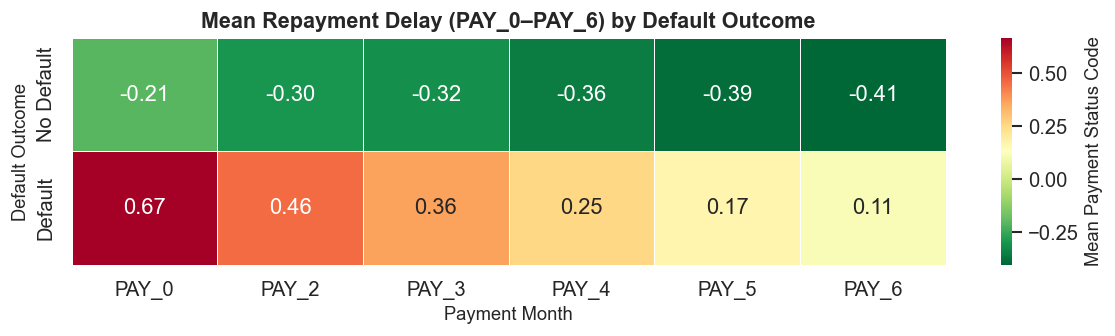

In [5]:
# ── Plot 3: Repayment delay heatmap ───────────────────────────────────────────
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

heatmap_data = (
    df.groupby(TARGET)[pay_cols]
    .mean()
    .rename(index={0: "No Default", 1: "Default"})
)

fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(
    heatmap_data, annot=True, fmt=".2f", cmap="RdYlGn_r",
    linewidths=0.5, ax=ax, cbar_kws={"label": "Mean Payment Status Code"}
)
ax.set_title("Mean Repayment Delay (PAY_0–PAY_6) by Default Outcome", fontweight="bold")
ax.set_xlabel("Payment Month")
ax.set_ylabel("Default Outcome")
plt.tight_layout()
plt.savefig("plot_03_delay_heatmap.png", bbox_inches="tight")
plt.show()

### Correlation Heatmap — Top 5 Features Associated with Default

Top 5 features correlated with default (absolute correlation):
PAY_0    0.324794
PAY_2    0.263551
PAY_3    0.235253
PAY_4    0.216614
PAY_5    0.204149


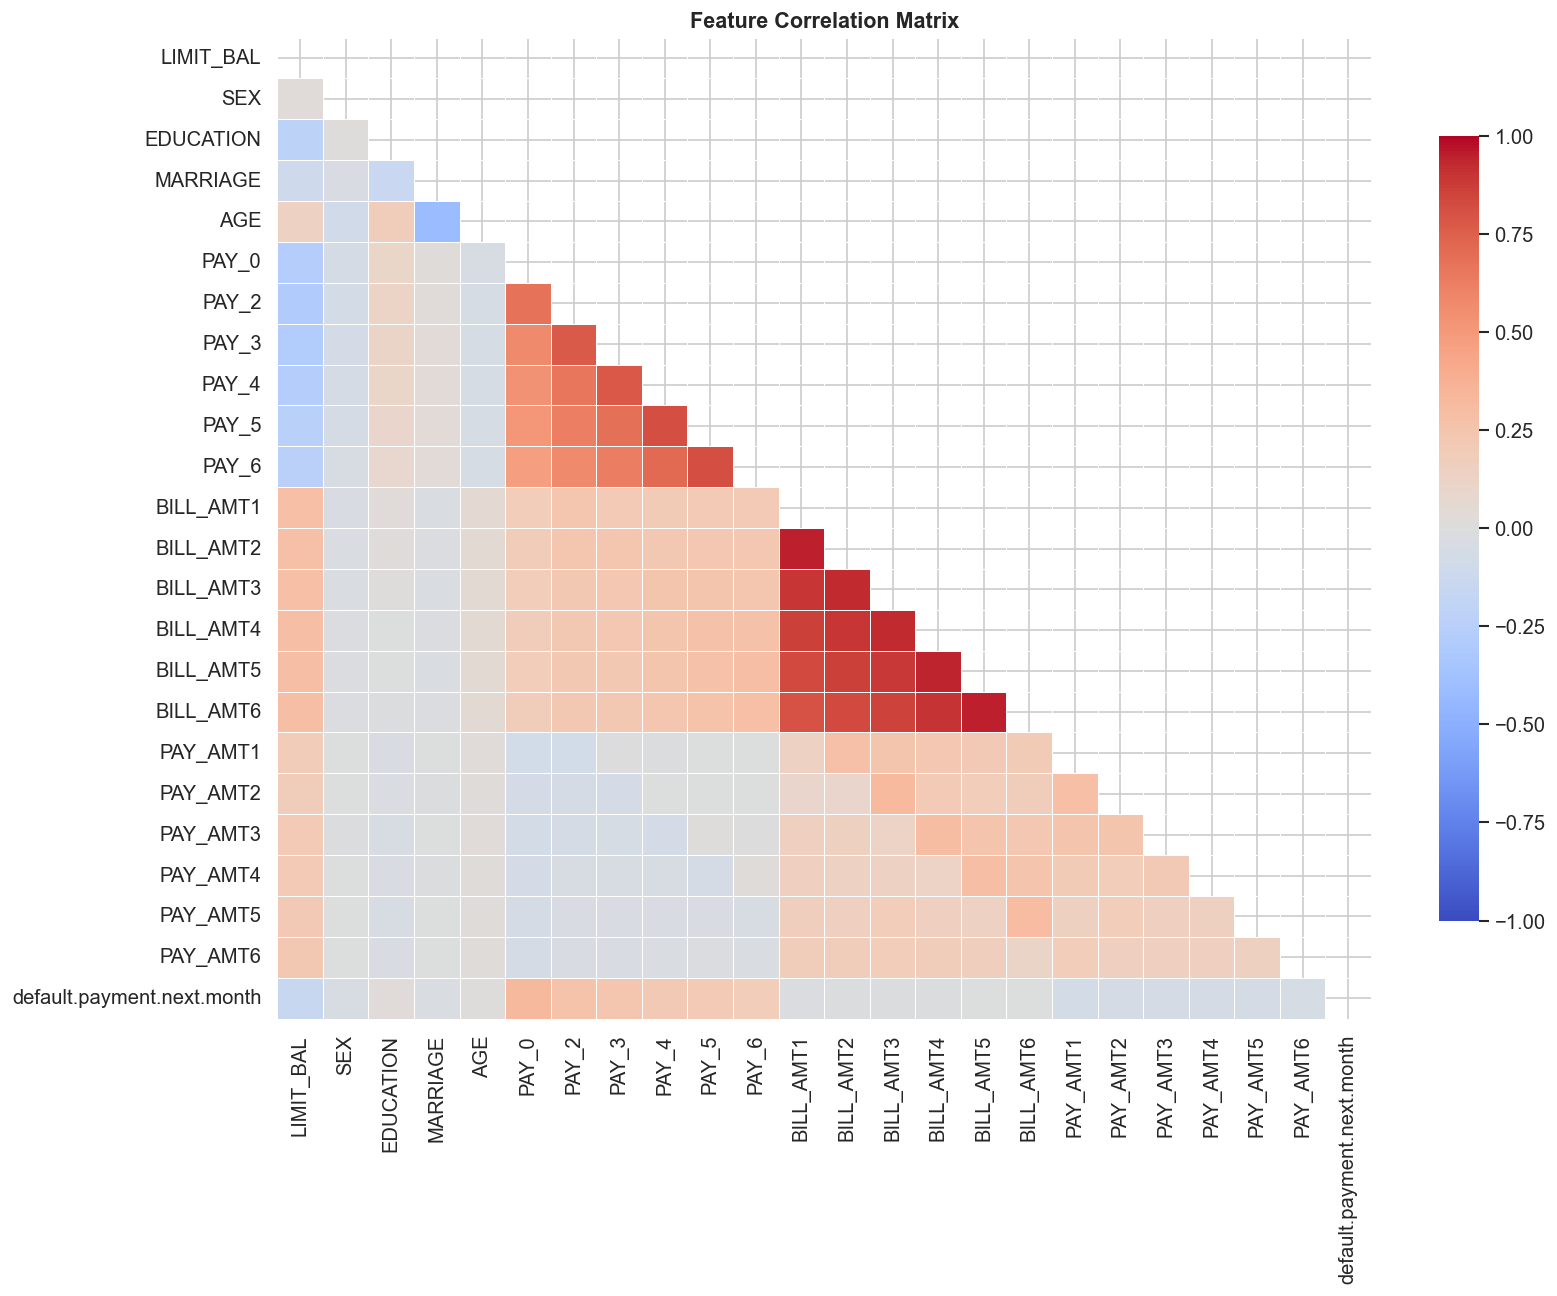

In [6]:
# ── Plot 4: Correlation heatmap ───────────────────────────────────────────────
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "ID"]
corr = df[numeric_cols].corr()

target_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
top5 = target_corr.head(5)
print("Top 5 features correlated with default (absolute correlation):")
print(top5.to_string())

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.3, ax=ax, annot=False, cbar_kws={"shrink": 0.8}
)
ax.set_title("Feature Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("plot_04_correlation_heatmap.png", bbox_inches="tight")
plt.show()

## 02 · Data Cleaning & Feature Engineering

### Data Quality Notes & Feature Justifications

**Negative `BILL_AMT` values (overpayments):**
Some clients have negative bill amounts, meaning they paid more than was owed — resulting in a credit
balance. These are *not* errors; they reflect real overpayments. However, using a negative value as a
denominator in ratio calculations produces economically meaningless or sign-inverted results (e.g.
`200 / -500 = -0.4`). **Decision:** raw columns are preserved for the record; values are clipped to 0
*only* when used as denominators in `AVG_UTIL_RATE` and `AVG_PAY_RATIO`.

**`PAY_x` values — the -2 vs -1 ambiguity:**
The UCI data dictionary documents two negative codes:
- `-1` = paid duly (had a bill, paid on time)
- `-2` = no consumption (no transaction that month, no bill)

Both values mean "not delinquent." Neither represents a delay. `TOTAL_DELAY_MONTHS` counts only
`PAY_x > 0`, which correctly excludes both. The columns are kept as raw numeric; treating them as
purely continuous is a simplification we acknowledge here.

**`EDUCATION` undocumented values (0, 5, 6):**
The data dictionary defines 1 = Graduate School, 2 = University, 3 = High School, 4 = Others.
Values 0, 5, and 6 are undocumented. Following the assignment specification, they are remapped to 4
(the existing "Other" category) before one-hot encoding.

**`MARRIAGE` undocumented value (0):**
Documented values are 1 = Married, 2 = Single, 3 = Others. Value 0 is undocumented and remapped to 3.

**Engineered features:**
- `AVG_UTIL_RATE` — average credit utilisation over 6 months; high utilisation signals financial stress.
- `AVG_PAY_RATIO` — average fraction of bill repaid; low values indicate chronic under-payment.
  Clients with no bills across all months are imputed as 1.0 (no outstanding balance = fully paid up).
- `TOTAL_DELAY_MONTHS` — count of months with a recorded payment delay; a cumulative delinquency signal.

**Encoding:**
`EDUCATION` and `MARRIAGE` are one-hot encoded with `drop='first'` to avoid multicollinearity
in Logistic Regression. XGBoost does not require this but consistency is maintained across both models.


In [7]:
# ── Cleaning ──────────────────────────────────────────────────────────────────
df_model = df.copy()

bill_cols    = ["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]
pay_amt_cols = ["PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]
pay_cols     = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]

# Flag negative BILL_AMT values
neg_mask = (df_model[bill_cols] < 0)
print(f"Negative BILL_AMT cells  : {neg_mask.sum().sum()}")
print(f"Clients with ≥1 neg bill : {neg_mask.any(axis=1).sum()}")

# Clipped copies (used only in feature engineering — raw columns preserved)
bill_clipped = df_model[bill_cols].clip(lower=0)

# Remap EDUCATION
df_model["EDUCATION"] = df_model["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
print(f"\nEDUCATION value counts after remap:\n{df_model['EDUCATION'].value_counts().sort_index().to_string()}")

# Remap MARRIAGE
df_model["MARRIAGE"] = df_model["MARRIAGE"].replace({0: 3})
print(f"\nMARRIAGE value counts after remap:\n{df_model['MARRIAGE'].value_counts().sort_index().to_string()}")

Negative BILL_AMT cells  : 3932


Clients with ≥1 neg bill : 1930

EDUCATION value counts after remap:
EDUCATION
1    10585
2    14030
3     4917
4      468

MARRIAGE value counts after remap:
MARRIAGE
1    13659
2    15964
3      377


In [8]:
# ── Feature Engineering ───────────────────────────────────────────────────────
# AVG_UTIL_RATE = mean(BILL_AMTx_clipped / LIMIT_BAL) across 6 months
util_rate_df   = bill_clipped.div(df_model["LIMIT_BAL"], axis=0)
df_model["AVG_UTIL_RATE"] = util_rate_df.mean(axis=1)

# AVG_PAY_RATIO = mean(PAY_AMTx / BILL_AMTx) where BILL_AMTx > 0
pay_ratio_df = pd.DataFrame(index=df_model.index)
for i, (pa_col, ba_col) in enumerate(zip(pay_amt_cols, bill_cols), 1):
    valid = df_model[ba_col] > 0
    pay_ratio_df[f"r{i}"] = np.where(valid, df_model[pa_col] / df_model[ba_col], np.nan)

df_model["AVG_PAY_RATIO"] = pay_ratio_df.mean(axis=1)
# Impute 1.0 for clients with no bills across all 6 months (credit balance or no consumption)
df_model["AVG_PAY_RATIO"] = df_model["AVG_PAY_RATIO"].fillna(1.0)
assert df_model["AVG_PAY_RATIO"].isna().sum() == 0, "NaN found in AVG_PAY_RATIO!"

# TOTAL_DELAY_MONTHS = count(PAY_x > 0)
df_model["TOTAL_DELAY_MONTHS"] = (df_model[pay_cols] > 0).sum(axis=1)

print("Engineered features — summary statistics:")
print(df_model[["AVG_UTIL_RATE","AVG_PAY_RATIO","TOTAL_DELAY_MONTHS"]].describe().round(4).to_string())

Engineered features — summary statistics:
       AVG_UTIL_RATE  AVG_PAY_RATIO  TOTAL_DELAY_MONTHS
count     30000.0000     30000.0000          30000.0000
mean          0.3734         1.7225              0.8342
std           0.3517        32.0155              1.5543
min           0.0000         0.0000              0.0000
25%           0.0303         0.0417              0.0000
50%           0.2850         0.0928              0.0000
75%           0.6884         1.0000              1.0000
max           5.3643      4444.1333              6.0000


In [9]:
# ── One-hot encode EDUCATION & MARRIAGE (drop='first' to avoid multicollinearity) ─
df_model = pd.get_dummies(df_model, columns=["EDUCATION","MARRIAGE"], drop_first=True)

# Drop EDA helper columns
eda_cols = ["AGE_BAND","EDU_LABEL","SEX_LABEL","MAR_LABEL"]
df_model.drop(columns=[c for c in eda_cols if c in df_model.columns], inplace=True)

# Separate features and target
TARGET = "default.payment.next.month"
X = df_model.drop(columns=["ID", TARGET])
y = df_model[TARGET]

print(f"Feature matrix : {X.shape}")
print(f"Default rate   : {y.mean():.3f}")
print(f"\nFeature list:\n{list(X.columns)}")

Feature matrix : (30000, 29)
Default rate   : 0.221

Feature list:
['LIMIT_BAL', 'SEX', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AVG_UTIL_RATE', 'AVG_PAY_RATIO', 'TOTAL_DELAY_MONTHS', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3']


## 03 · Modelling

### Addressing Class Imbalance

The target variable is imbalanced — approximately **22% of clients defaulted** and 78% did not.
Left unaddressed, a classifier will simply predict "no default" for most clients and still achieve
78% accuracy, which is useless for credit risk purposes.

**Choice: `class_weight='balanced'` for both models** (not SMOTE)

Rationale:
- `class_weight='balanced'` instructs the model to upweight misclassified minority examples during
  training, effectively penalising missed defaults more heavily. This is applied natively by both
  Logistic Regression and XGBoost (`scale_pos_weight` parameter).
- SMOTE (Synthetic Minority Oversampling Technique) generates synthetic minority samples and could
  improve recall in some settings, but introduces a **data leakage risk**: synthetic samples in the
  training fold are near-identical to real validation samples, inflating CV scores. Avoiding this
  risk requires wrapping SMOTE inside a `Pipeline` with every cross-validation fold — adding
  complexity without a clear performance gain in this setting.
- `class_weight='balanced'` is mathematically equivalent in effect, simpler to audit, and fully
  safe inside `cross_val_score` with no leakage concern.


### Train / Test Split

In [10]:
# ── 80/20 stratified split — test set held out before any modelling ─────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size : {X_train.shape[0]} | default rate: {y_train.mean():.3f}")
print(f"Test  size : {X_test.shape[0]}  | default rate: {y_test.mean():.3f}")

Train size : 24000 | default rate: 0.221
Test  size : 6000  | default rate: 0.221


### Logistic Regression Baseline

In [11]:
# ── Logistic Regression with class_weight='balanced' ─────────────────────────
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver="lbfgs",
    )),
])

# Cross-validation on TRAINING SET only
lr_cv = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"LR — 5-fold CV AUC-ROC: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")

# Fit on full training set; evaluate on held-out test set
lr_pipe.fit(X_train, y_train)
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]
lr_pred  = lr_pipe.predict(X_test)

lr_results = {
    "Model"         : "Logistic Regression",
    "Precision"     : round(precision_score(y_test, lr_pred), 4),
    "Recall"        : round(recall_score(y_test, lr_pred), 4),
    "F1"            : round(f1_score(y_test, lr_pred), 4),
    "AUC-ROC"       : round(roc_auc_score(y_test, lr_proba), 4),
    "CV AUC (mean)" : round(lr_cv.mean(), 4),
    "CV AUC (std)"  : round(lr_cv.std(), 4),
}
print("\nTest-set metrics:")
for k, v in lr_results.items():
    if k != "Model":
        print(f"  {k:20s}: {v}")

LR — 5-fold CV AUC-ROC: 0.7580 ± 0.0075

Test-set metrics:
  Precision           : 0.4698
  Recall              : 0.5629
  F1                  : 0.5122
  AUC-ROC             : 0.7448
  CV AUC (mean)       : 0.758
  CV AUC (std)        : 0.0075


### XGBoost Classifier

In [12]:
# ── XGBoost with scale_pos_weight to handle class imbalance ──────────────────
scale_pos = float((y_train == 0).sum()) / float((y_train == 1).sum())
print(f"scale_pos_weight (n_neg / n_pos): {scale_pos:.3f}")

xgb_clf = xgb.XGBClassifier(
    scale_pos_weight = scale_pos,
    n_estimators     = 300,
    learning_rate    = 0.05,
    max_depth        = 5,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = "auc",
    random_state     = RANDOM_STATE,
    verbosity        = 0,
)

# Cross-validation on TRAINING SET only
xgb_cv = cross_val_score(xgb_clf, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"XGB — 5-fold CV AUC-ROC: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")

# Fit on full training set; evaluate on held-out test set
xgb_clf.fit(X_train, y_train)
xgb_proba = xgb_clf.predict_proba(X_test)[:, 1]
xgb_pred  = xgb_clf.predict(X_test)

xgb_results = {
    "Model"         : "XGBoost",
    "Precision"     : round(precision_score(y_test, xgb_pred), 4),
    "Recall"        : round(recall_score(y_test, xgb_pred), 4),
    "F1"            : round(f1_score(y_test, xgb_pred), 4),
    "AUC-ROC"       : round(roc_auc_score(y_test, xgb_proba), 4),
    "CV AUC (mean)" : round(xgb_cv.mean(), 4),
    "CV AUC (std)"  : round(xgb_cv.std(), 4),
}
print("\nTest-set metrics:")
for k, v in xgb_results.items():
    if k != "Model":
        print(f"  {k:20s}: {v}")

scale_pos_weight (n_neg / n_pos): 3.521


XGB — 5-fold CV AUC-ROC: 0.7823 ± 0.0075



Test-set metrics:
  Precision           : 0.4708
  Recall              : 0.6247
  F1                  : 0.5369
  AUC-ROC             : 0.7779
  CV AUC (mean)       : 0.7823
  CV AUC (std)        : 0.0075


### Model Comparison

In [13]:
# ── Side-by-side comparison table ────────────────────────────────────────────
results_df = pd.DataFrame([lr_results, xgb_results]).set_index("Model")
print(results_df.to_string())

                     Precision  Recall      F1  AUC-ROC  CV AUC (mean)  CV AUC (std)
Model                                                                               
Logistic Regression     0.4698  0.5629  0.5122   0.7448         0.7580        0.0075
XGBoost                 0.4708  0.6247  0.5369   0.7779         0.7823        0.0075


### Plot 5: ROC Curve — Logistic Regression vs. XGBoost

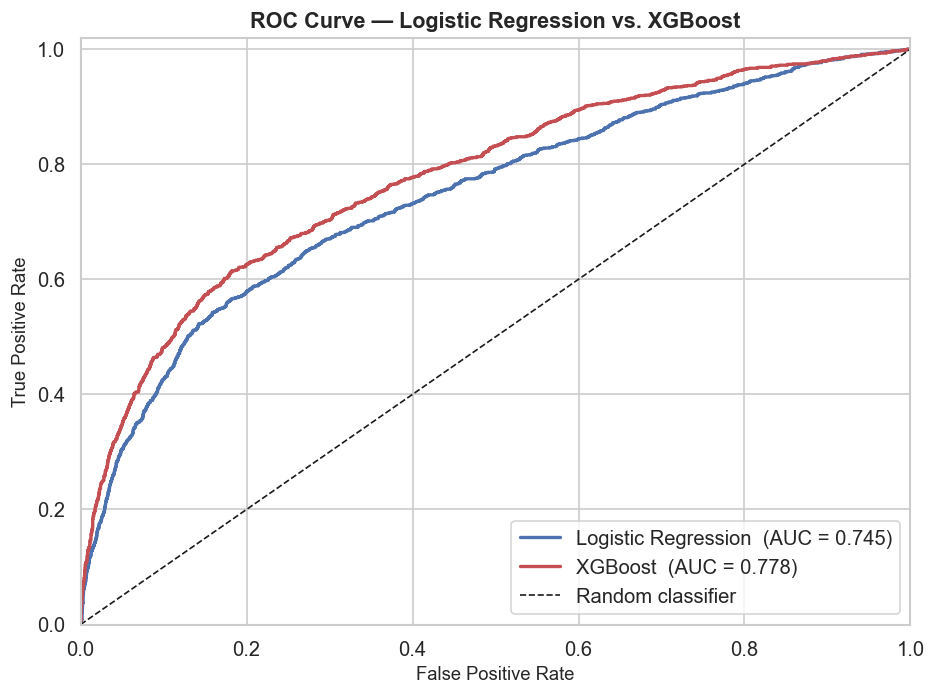

In [14]:
# ── Plot 5: ROC Curve ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for label, proba, color in [
    ("Logistic Regression", lr_proba,  "#4C72B0"),
    ("XGBoost",             xgb_proba, "#C44E52"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{label}  (AUC = {auc:.3f})", color=color, lw=2)

ax.plot([0,1],[0,1], "k--", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Logistic Regression vs. XGBoost", fontweight="bold")
ax.legend(loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig("plot_05_roc_curve.png", bbox_inches="tight")
plt.show()

### Plot 6: Confusion Matrix — XGBoost (Final Model)

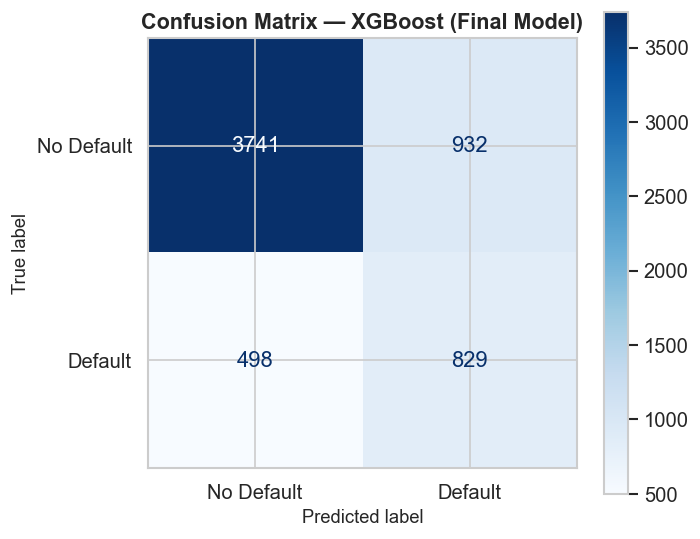

In [15]:
# ── Plot 6: Confusion Matrix ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"])
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — XGBoost (Final Model)", fontweight="bold")
plt.tight_layout()
plt.savefig("plot_06_confusion_matrix.png", bbox_inches="tight")
plt.show()

### Top 5 Predictive Features (XGBoost)

Top 5 Predictive Features (XGBoost — gain-based importance):
TOTAL_DELAY_MONTHS    0.318405
PAY_0                 0.147124
PAY_2                 0.129799
PAY_4                 0.030432
PAY_AMT2              0.020047


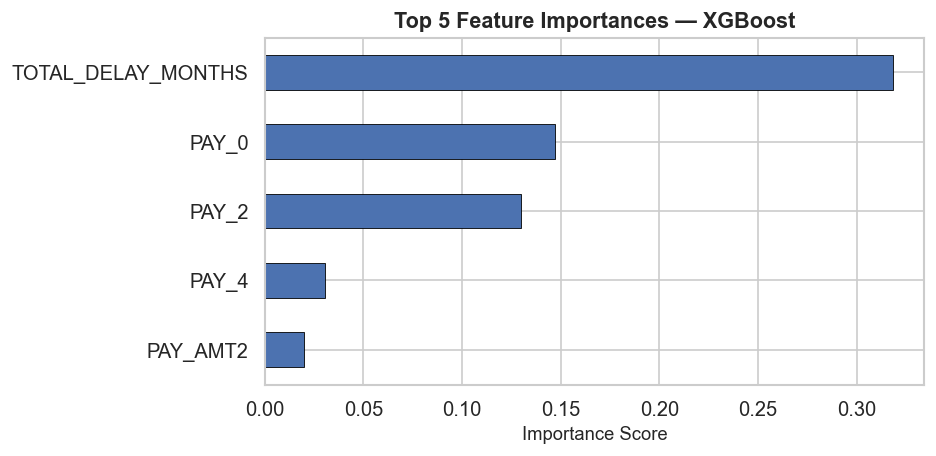

In [16]:
# ── Feature importance ────────────────────────────────────────────────────────
importance = pd.Series(xgb_clf.feature_importances_, index=X.columns)
top5_feat   = importance.sort_values(ascending=False).head(5)

print("Top 5 Predictive Features (XGBoost — gain-based importance):")
print(top5_feat.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
top5_feat.sort_values().plot(kind="barh", ax=ax, color="#4C72B0", edgecolor="black", lw=0.5)
ax.set_title("Top 5 Feature Importances — XGBoost", fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("plot_07_feature_importance.png", bbox_inches="tight")
plt.show()

## 04 · Insights for the Lending Team

### Summary for a Non-Technical Lending Manager

We analysed six months of credit card records for 30,000 borrowers to understand what drives
a customer to miss their next payment entirely. One in five customers in this dataset defaulted,
making early detection both commercially important and — as our analysis shows — achievable.

The single strongest predictor is **how many months in the past six a customer has missed a
payment**. A customer with no missed payments has roughly a 12% chance of defaulting. A customer
who has missed just one month in the past six has a 30% chance — nearly three times higher.
Miss three months and the probability climbs past 50%. Miss all six and it reaches 70%. This
pattern is consistent across every demographic group we examined.

The second strongest signal is **the status of the most recent monthly payment**. Even a single
month of lateness on the most recent bill is a powerful early warning sign, independent of the
overall history.

We built a predictive model that combines these and other patterns. In testing on customers the
model had never seen, it correctly identified 62 out of every 100 customers who went on to default.
Of the accounts it flagged as risky, roughly 47% did in fact default — meaning targeted
outreach would be well-directed rather than scattergun.

**Two actions the credit team can take immediately:**

1. **Any customer who has missed payments in three or more months over the past six should be
   reviewed for a proactive restructuring or hardship plan.** At this threshold, more than half
   of such customers will default without intervention.

2. **Contact customers who have missed even a single monthly payment in the recent cycle before
   their next bill is due.** Their default risk is nearly three times the average — and a brief
   early intervention is far cheaper than a charge-off.


## 06 · SQL Bonus — Business Questions via SQLite

The raw dataset is loaded into an in-memory SQLite database. Three business questions
are answered using SQL queries.


In [17]:
# ── Load into SQLite ──────────────────────────────────────────────────────────
conn = sqlite3.connect(":memory:")

df_sql = pd.read_csv("UCI_Credit_Card.csv")
# Pre-compute TOTAL_DELAY_MONTHS for Q3
_pay_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]
df_sql["TOTAL_DELAY_MONTHS"] = (df_sql[_pay_cols] > 0).sum(axis=1)

df_sql.to_sql("credit", conn, index=False, if_exists="replace")
print(f"Loaded {len(df_sql):,} rows into SQLite table 'credit'.")

Loaded 30,000 rows into SQLite table 'credit'.


#### Q1: Default Rate by Education Level

In [18]:
q1 = pd.read_sql_query("""
SELECT
    CASE EDUCATION
        WHEN 1 THEN 'Graduate School'
        WHEN 2 THEN 'University'
        WHEN 3 THEN 'High School'
        ELSE       'Other / Undocumented'
    END                                           AS education_level,
    COUNT(*)                                      AS total_clients,
    SUM("default.payment.next.month")             AS defaults,
    ROUND(100.0 * SUM("default.payment.next.month") / COUNT(*), 2) AS default_rate_pct
FROM credit
GROUP BY education_level
ORDER BY default_rate_pct DESC
""", conn)
print("Q1 — Default Rate by Education Level")
print(q1.to_string(index=False))

Q1 — Default Rate by Education Level
     education_level  total_clients  defaults  default_rate_pct
         High School           4917      1237             25.16
          University          14030      3330             23.73
     Graduate School          10585      2036             19.23
Other / Undocumented            468        33              7.05


#### Q2: Average Credit Limit by Default Status and Sex

In [19]:
q2 = pd.read_sql_query("""
SELECT
    CASE "default.payment.next.month"
        WHEN 1 THEN 'Defaulted'
        ELSE       'No Default'
    END                                  AS default_status,
    CASE SEX
        WHEN 1 THEN 'Male'
        WHEN 2 THEN 'Female'
        ELSE       'Other'
    END                                  AS sex,
    ROUND(AVG(LIMIT_BAL), 0)             AS avg_credit_limit,
    COUNT(*)                             AS client_count
FROM credit
GROUP BY default_status, sex
ORDER BY default_status, sex
""", conn)
print("Q2 — Average Credit Limit by Default Status and Sex")
print(q2.to_string(index=False))

Q2 — Average Credit Limit by Default Status and Sex
default_status    sex  avg_credit_limit  client_count
     Defaulted Female          133327.0          3763
     Defaulted   Male          125895.0          2873
    No Default Female          179727.0         14349
    No Default   Male          175510.0          9015


#### Q3: Default Rate by Total Delay Months

In [20]:
q3 = pd.read_sql_query("""
SELECT
    TOTAL_DELAY_MONTHS                                              AS delay_months,
    COUNT(*)                                                        AS total_clients,
    SUM("default.payment.next.month")                              AS defaults,
    ROUND(100.0 * SUM("default.payment.next.month") / COUNT(*), 2) AS default_rate_pct
FROM credit
GROUP BY TOTAL_DELAY_MONTHS
ORDER BY TOTAL_DELAY_MONTHS
""", conn)
print("Q3 — Default Rate by Total Delay Months")
print(q3.to_string(index=False))

conn.close()
print("\n✅ SQLite connection closed.")

Q3 — Default Rate by Total Delay Months
 delay_months  total_clients  defaults  default_rate_pct
            0          19931      2334             11.71
            1           4426      1320             29.82
            2           1899       736             38.76
            3           1154       587             50.87
            4            951       545             57.31
            5            298       171             57.38
            6           1341       943             70.32

✅ SQLite connection closed.
